In [17]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 1. 终极清晰度设置
plt.rcParams.update({
    'figure.dpi': 1200,
    'savefig.dpi': 1200,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'lines.linewidth': 3,
    'lines.markersize': 12,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
})

# 2. 精确字体控制（确保系统已安装这些字体）
try:
    chinese_font = fm.FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=14)
except:
    try:
        chinese_font = fm.FontProperties(fname='/System/Library/Fonts/STHeiti Medium.ttc', size=14)
    except:
        chinese_font = fm.FontProperties(size=14)

try:
    english_font = fm.FontProperties(fname='C:/Windows/Fonts/times.ttf', size=14)
except:
    english_font = fm.FontProperties(size=14)

# 3. 创建图表
fig, ax = plt.subplots(figsize=(10, 7), dpi=1200)
fig.set_facecolor('white')

# 4. 数据准备
conditions = ['自然光', '室内光', '低光']
rgb_acc = [85.0, 80.0, 75.0]
hsv_acc = [90.2, 88.3, 83.7]

# 5. 绘图样式
line_styles = {
    'RGB': {'color': '#1f77b4', 'marker': 'D', 'ls': '-', 'lw': 3},
    'HSV': {'color': '#ff7f0e', 'marker': 'o', 'ls': '--', 'lw': 3}
}

# 6. 绘制折线图
for name, acc in zip(['RGB', 'HSV'], [rgb_acc, hsv_acc]):
    ax.plot(conditions, acc, label=name, **line_styles[name],
            markeredgewidth=2, markeredgecolor='w')

# 7. 添加标注
for model, acc, offset in zip(['RGB', 'HSV'], [rgb_acc, hsv_acc], [10, -15]):
    for x, y in zip(conditions, acc):
        ax.annotate(f'{y:.1f}%', (x, y), xytext=(5, offset),
                    textcoords='offset points', ha='left', va='center',
                    fontsize=12, fontproperties=english_font,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.9))

# 8. 设置坐标轴标签
ax.set_xlabel('Lighting Conditions', fontproperties=english_font, labelpad=15)
ax.set_ylabel('Segmentation Accuracy (%)', fontproperties=english_font, labelpad=15)

# 9. 坐标刻度
ax.tick_params(axis='both', which='major', length=6, width=1.5, labelsize=13)
plt.xticks(fontproperties=chinese_font)
plt.yticks(np.arange(70, 101, 5), fontproperties=english_font, fontsize=13)

# 10. 图例设置
legend = ax.legend(prop=english_font, loc='upper right',
                   frameon=True, framealpha=0.95,
                   edgecolor='#333333', facecolor='white',
                   borderpad=1, handlelength=2)
legend.get_title().set_fontweight('bold')

# 11. 背景与网格
ax.grid(True, which='both', linestyle=':', linewidth=1, alpha=0.7)
ax.set_facecolor('#f9f9f9')
ax.spines[:].set_linewidth(1.5)

# 12. 保存和显示
plt.tight_layout(pad=2)
plt.savefig('RGB与HSV对比.png', dpi=1200, bbox_inches='tight')
plt.show()


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# 1. 高级图形参数设置
plt.rcParams.update({
    'figure.dpi': 1200,
    'savefig.dpi': 1200,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
})

# 2. 精确字体控制（确保系统已安装这些字体）
try:
    # Windows系统字体
    chinese_font = fm.FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=14)
except:
    try:
        # Mac系统字体
        chinese_font = fm.FontProperties(fname='/System/Library/Fonts/STHeiti Medium.ttc', size=14)
    except:
        # 备用方案
        chinese_font = fm.FontProperties(size=14)

# 3. 数据准备
mu, sigma = 128, 30
x = np.linspace(0, 255, 500)
pdf = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2/(2*sigma**2))

k = 1.5
t_low = mu - k*sigma
t_high = mu + k*sigma

np.random.seed(0)
v_channel = np.random.normal(mu, sigma, 10000).clip(0, 255).astype(np.uint8)
hist_vals, bin_edges = np.histogram(v_channel, bins=50, range=(0, 255))
bin_centers = (bin_edges[:-1] + bin_edges[1:])/2

# 4. 创建图形
fig, ax1 = plt.subplots(figsize=(10, 6), facecolor='white')
fig.subplots_adjust(left=0.1, right=0.85)  # 为右侧坐标轴留空间

# 5. 绘制直方图（优化视觉参数）
hist_bars = ax1.bar(bin_centers, hist_vals, width=5, alpha=0.6, 
                   color='#1f77b4', edgecolor='#1f77b4', linewidth=0.5,
                   label='V通道像素分布')

# 6. 绘制正态分布曲线（右侧坐标轴）
ax2 = ax1.twinx()
pdf_line, = ax2.plot(x, pdf*max(hist_vals)*20, color='#d62728', 
                    linewidth=2.5, linestyle='-', label='正态分布拟合')

# 7. 绘制阈值线（带自定义图例）
threshold_lines = []
for val, color, label in zip([mu, t_low, t_high], 
                            ['#2ca02c', '#ff7f0e', '#ff7f0e'],
                            ['μ (均值)', 'T$_{low}$=μ-1.5σ', 'T$_{high}$=μ+1.5σ']):
    line = ax1.axvline(val, color=color, linestyle='--', linewidth=2, alpha=0.8)
    threshold_lines.append(line)

# 8. 坐标轴设置
ax1.set_xlabel('像素亮度值', fontproperties=chinese_font)
ax1.set_ylabel('像素数量', fontproperties=chinese_font)
ax2.set_ylabel('概率密度（缩放后）', fontproperties=chinese_font)

# 9. 标题设置（中英双语）
title = ax1.set_title('V通道亮度分布及动态阈值设定示意图\nV-channel Intensity Distribution with Dynamic Thresholds', 
                     fontproperties=chinese_font, pad=20)
title._fontproperties = chinese_font  # 确保中文标题正确渲染

# 10. 调整后的整合图例信息
from matplotlib.lines import Line2D

# 自定义所有图例元素
custom_legend_elements = [
    Line2D([0], [0], color='#1f77b4', lw=3, label='V通道像素分布'),
    Line2D([0], [0], color='#d62728', lw=2.5, label='正态分布拟合'),
    Line2D([0], [0], color='#2ca02c', linestyle='--', lw=2, label='μ (均值)'),
    Line2D([0], [0], color='#ff7f0e', linestyle='--', lw=2, label='T$_{low}$ / T$_{high}$')
]

# 设置图例位置为右上角，适当缩小字体
ax1.legend(handles=custom_legend_elements,
           loc='upper right',
           bbox_to_anchor=(0.98, 0.98),
           frameon=True,
           facecolor='white',
           edgecolor='black',
           prop=fm.FontProperties(size=11))  # 缩小字体

# 11. 网格和刻度优化
ax1.grid(True, which='major', linestyle=':', linewidth=0.7, alpha=0.5)
ax1.set_axisbelow(True)
ax1.set_xlim(0, 255)
ax1.set_ylim(0, max(hist_vals)*1.1)
ax2.set_ylim(0, max(pdf*max(hist_vals)*20)*1.1)

# 12. 刻度字体设置
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontproperties(chinese_font)

# 13. 保存输出
plt.tight_layout()
# plt.savefig('v_channel_distribution.pdf', format='pdf', bbox_inches='tight')
plt.savefig('v_channel_distribution.png', dpi=1200, bbox_inches='tight')
plt.show()

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像并转为灰度
img = cv2.imread('./test_pic/between_region.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 自适应阈值（二值化）或 Otsu
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 如果字符是黑色（背景是白的），则需要反转颜色
# 判断黑白反转逻辑
white_pixel_ratio = np.sum(binary == 255) / binary.size
if white_pixel_ratio < 0.5:
    binary = cv2.bitwise_not(binary)

# 定义结构元素，先试较小的 3x3 或 5x5
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))

# 闭运算
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# 显示图像对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title('闭运算后')
plt.axis('off')

plt.subplot(1, 2, 1)
plt.imshow(closed, cmap='gray')
plt.title('闭运算前')
plt.axis('off')

plt.tight_layout()
plt.savefig('./test_pic/morph_close_fixed_compare.png', dpi=300, bbox_inches='tight')
plt.show()


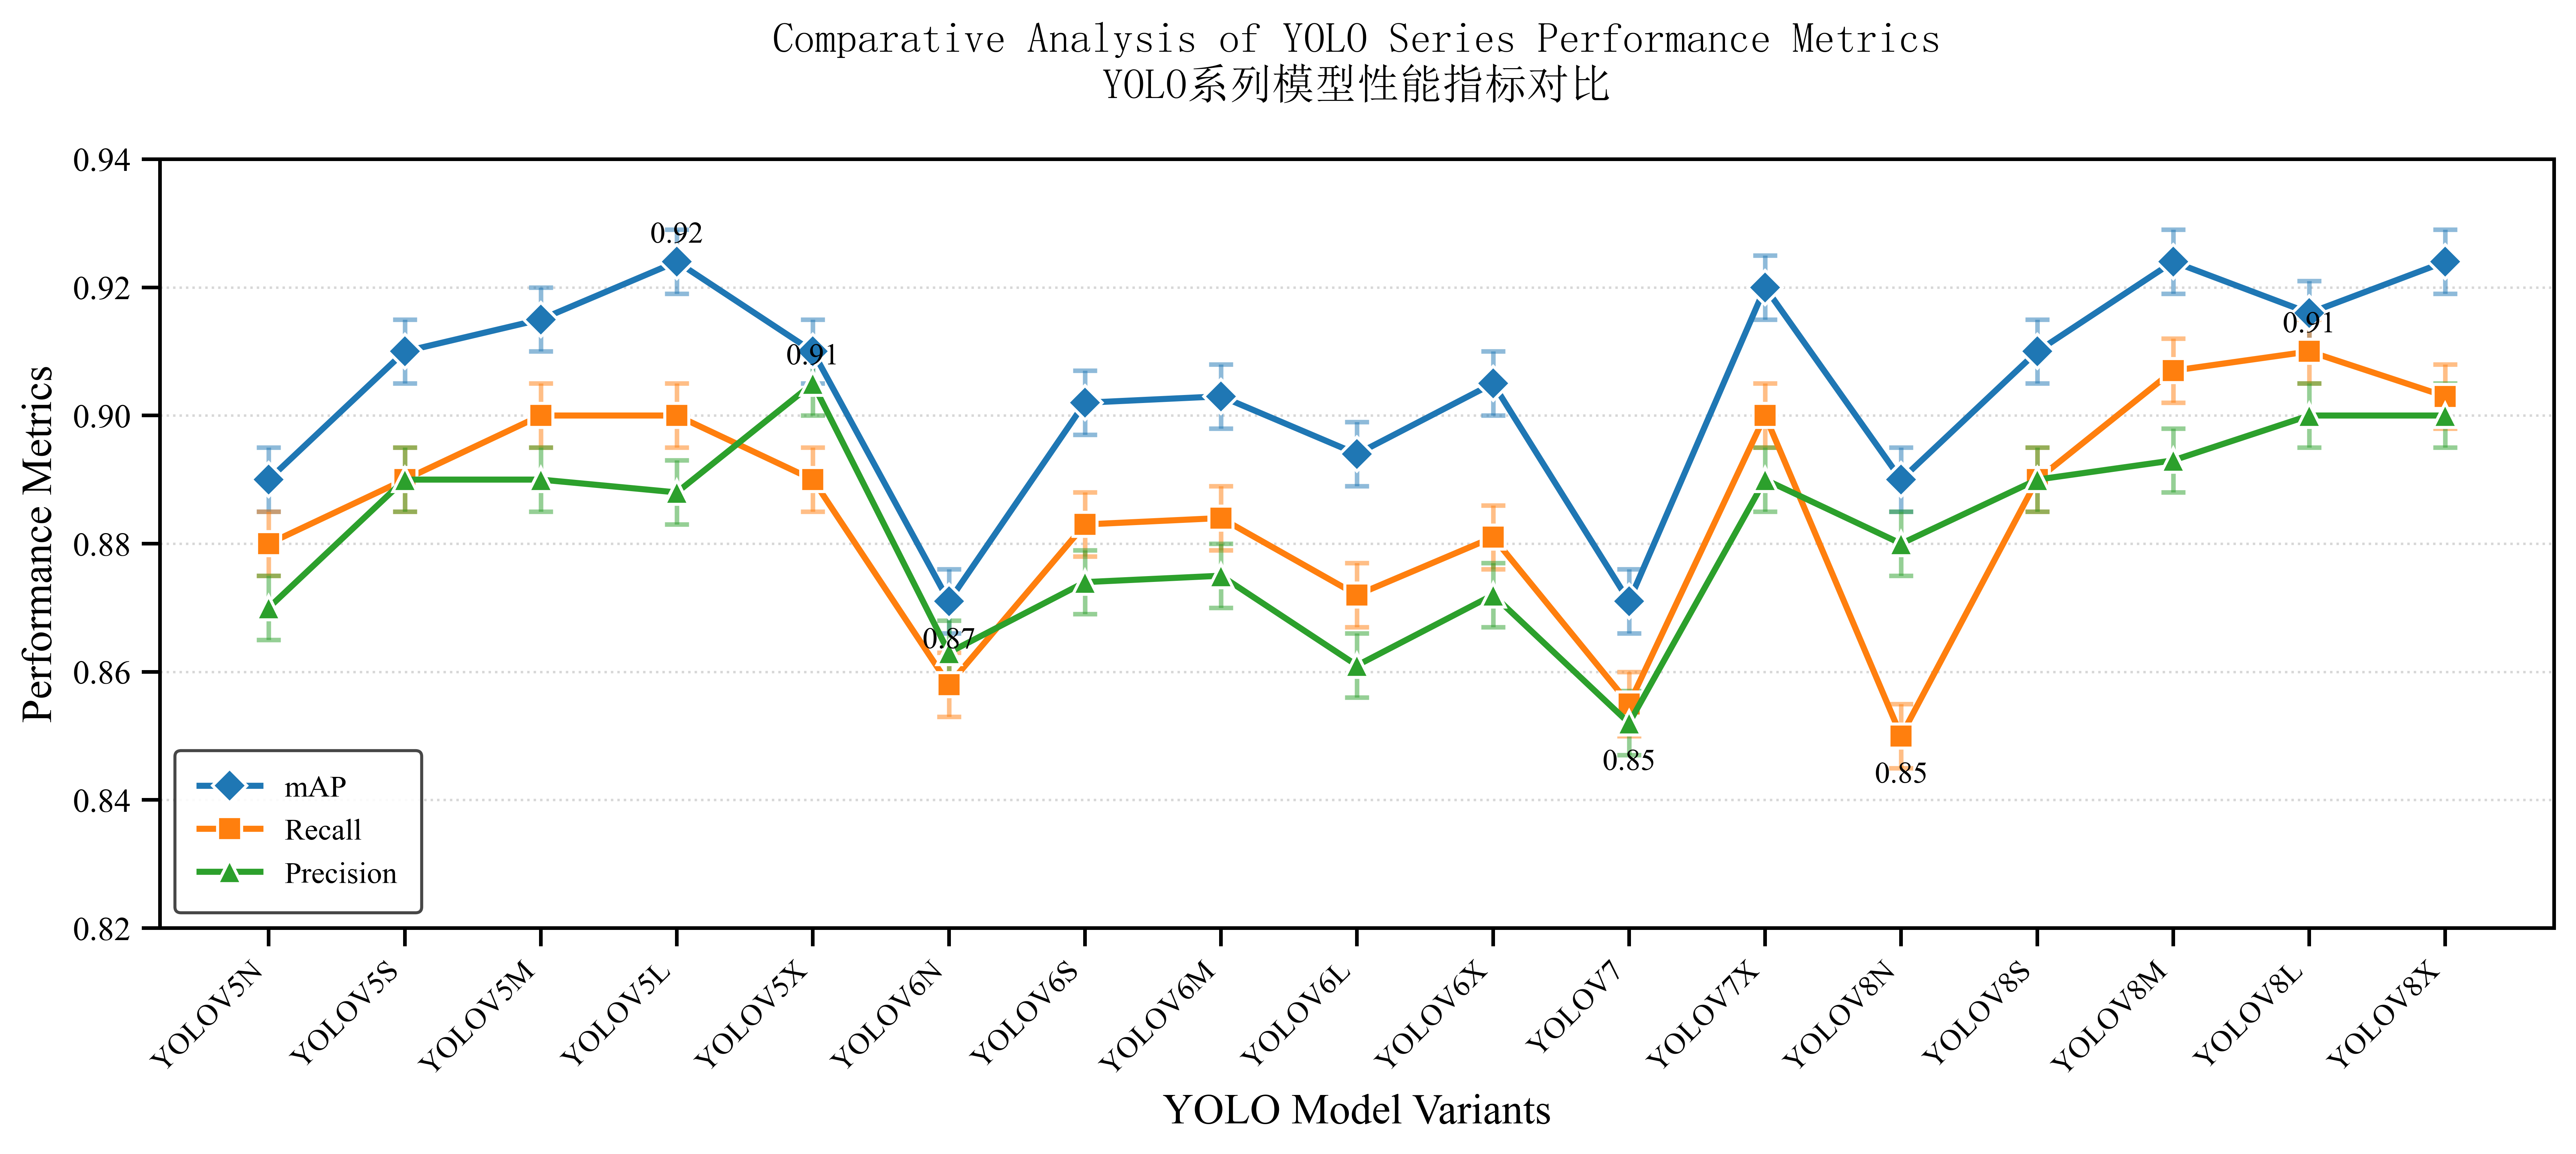

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# ==================== 字体设置（中英文） ====================
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 14,  # 小五字号 ≈ 10.5 pt
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False
})

# 设置中文字体为宋体，字号为小五（约10.5pt）
try:
    chinese_font = fm.FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=14)
except:
    try:
        chinese_font = fm.FontProperties(fname='/System/Library/Fonts/STHeiti Medium.ttc', size=14)
    except:
        chinese_font = fm.FontProperties(size=14)

# ==================== 数据准备 ====================
models = ['YOLOV5N', 'YOLOV5S', 'YOLOV5M', 'YOLOV5L', 'YOLOV5X',
          'YOLOV6N', 'YOLOV6S', 'YOLOV6M', 'YOLOV6L', 'YOLOV6X',
          'YOLOV7', 'YOLOV7X', 'YOLOV8N', 'YOLOV8S', 'YOLOV8M', 'YOLOV8L', 'YOLOV8X']
metrics = {
    'mAP': [0.89, 0.91, 0.915, 0.924, 0.91, 
            0.871, 0.902, 0.903, 0.894, 0.905, 
            0.871,0.92, 0.89, 0.91, 0.924, 0.916, 0.924],
    'Recall': [0.88, 0.89, 0.90, 0.90, 0.89, 
               0.858, 0.883, 0.884, 0.872, 0.881,
               0.855, 0.90, 0.85, 0.89, 0.907, 0.91, 0.903],
    'Precision': [0.87, 0.89, 0.89, 0.888, 0.905, 
                  0.863, 0.874, 0.875, 0.861, 0.872, 
                  0.852, 0.89, 0.88, 0.89, 0.893, 0.90, 0.90]
}
error = [0.005] * len(models)

# ==================== 图表绘制 ====================
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=600)
fig.subplots_adjust(bottom=0.25)

colors = {
    'mAP': '#1f77b4',
    'Recall': '#ff7f0e',
    'Precision': '#2ca02c'
}

x = np.arange(len(models))

# 绘制误差线
for metric, color in colors.items():
    ax.errorbar(x, metrics[metric], yerr=error, fmt='none',
                ecolor=color, elinewidth=1.5, capsize=4, capthick=1.5, alpha=0.5)

# 绘制折线图
markers = {'mAP': 'D', 'Recall': 's', 'Precision': '^'}
for metric, color in colors.items():
    y = metrics[metric]
    ax.plot(x, y, marker=markers[metric], label=metric,
            color=color, markersize=8, markeredgewidth=1,
            markeredgecolor='w', linewidth=2, linestyle='-')

    # 添加最大值和最小值的标注
    y_max, y_min = max(y), min(y)
    x_max, x_min = y.index(y_max), y.index(y_min)
    ax.text(x_max, y_max + 0.002, f'{y_max:.2f}', ha='center', va='bottom', fontsize=10)
    ax.text(x_min, y_min - 0.004, f'{y_min:.2f}', ha='center', va='top', fontsize=10)

# ==================== 学术级格式设置 ====================
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0.82, 0.94)
ax.set_yticks(np.arange(0.82, 0.95, 0.02))

# 坐标轴标题
ax.set_xlabel('YOLO Model Variants', fontsize=14)
ax.set_ylabel('Performance Metrics', fontsize=14)
ax.set_title('Comparative Analysis of YOLO Series Performance Metrics\nYOLO系列模型性能指标对比',
             fontproperties=chinese_font, pad=20)

# 图例
ax.legend(frameon=True, framealpha=0.9, edgecolor='#333333',
          facecolor='white', fontsize=10, borderpad=0.8)

# 网格与边框
ax.grid(True, axis='y', linestyle=':', linewidth=0.8, alpha=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
ax.tick_params(axis='both', which='major', length=6, width=1.2)

# ==================== 保存与显示 ====================
plt.tight_layout()
plt.savefig('YOLO_Performance_Comparison.png', dpi=600, bbox_inches='tight')
plt.show()


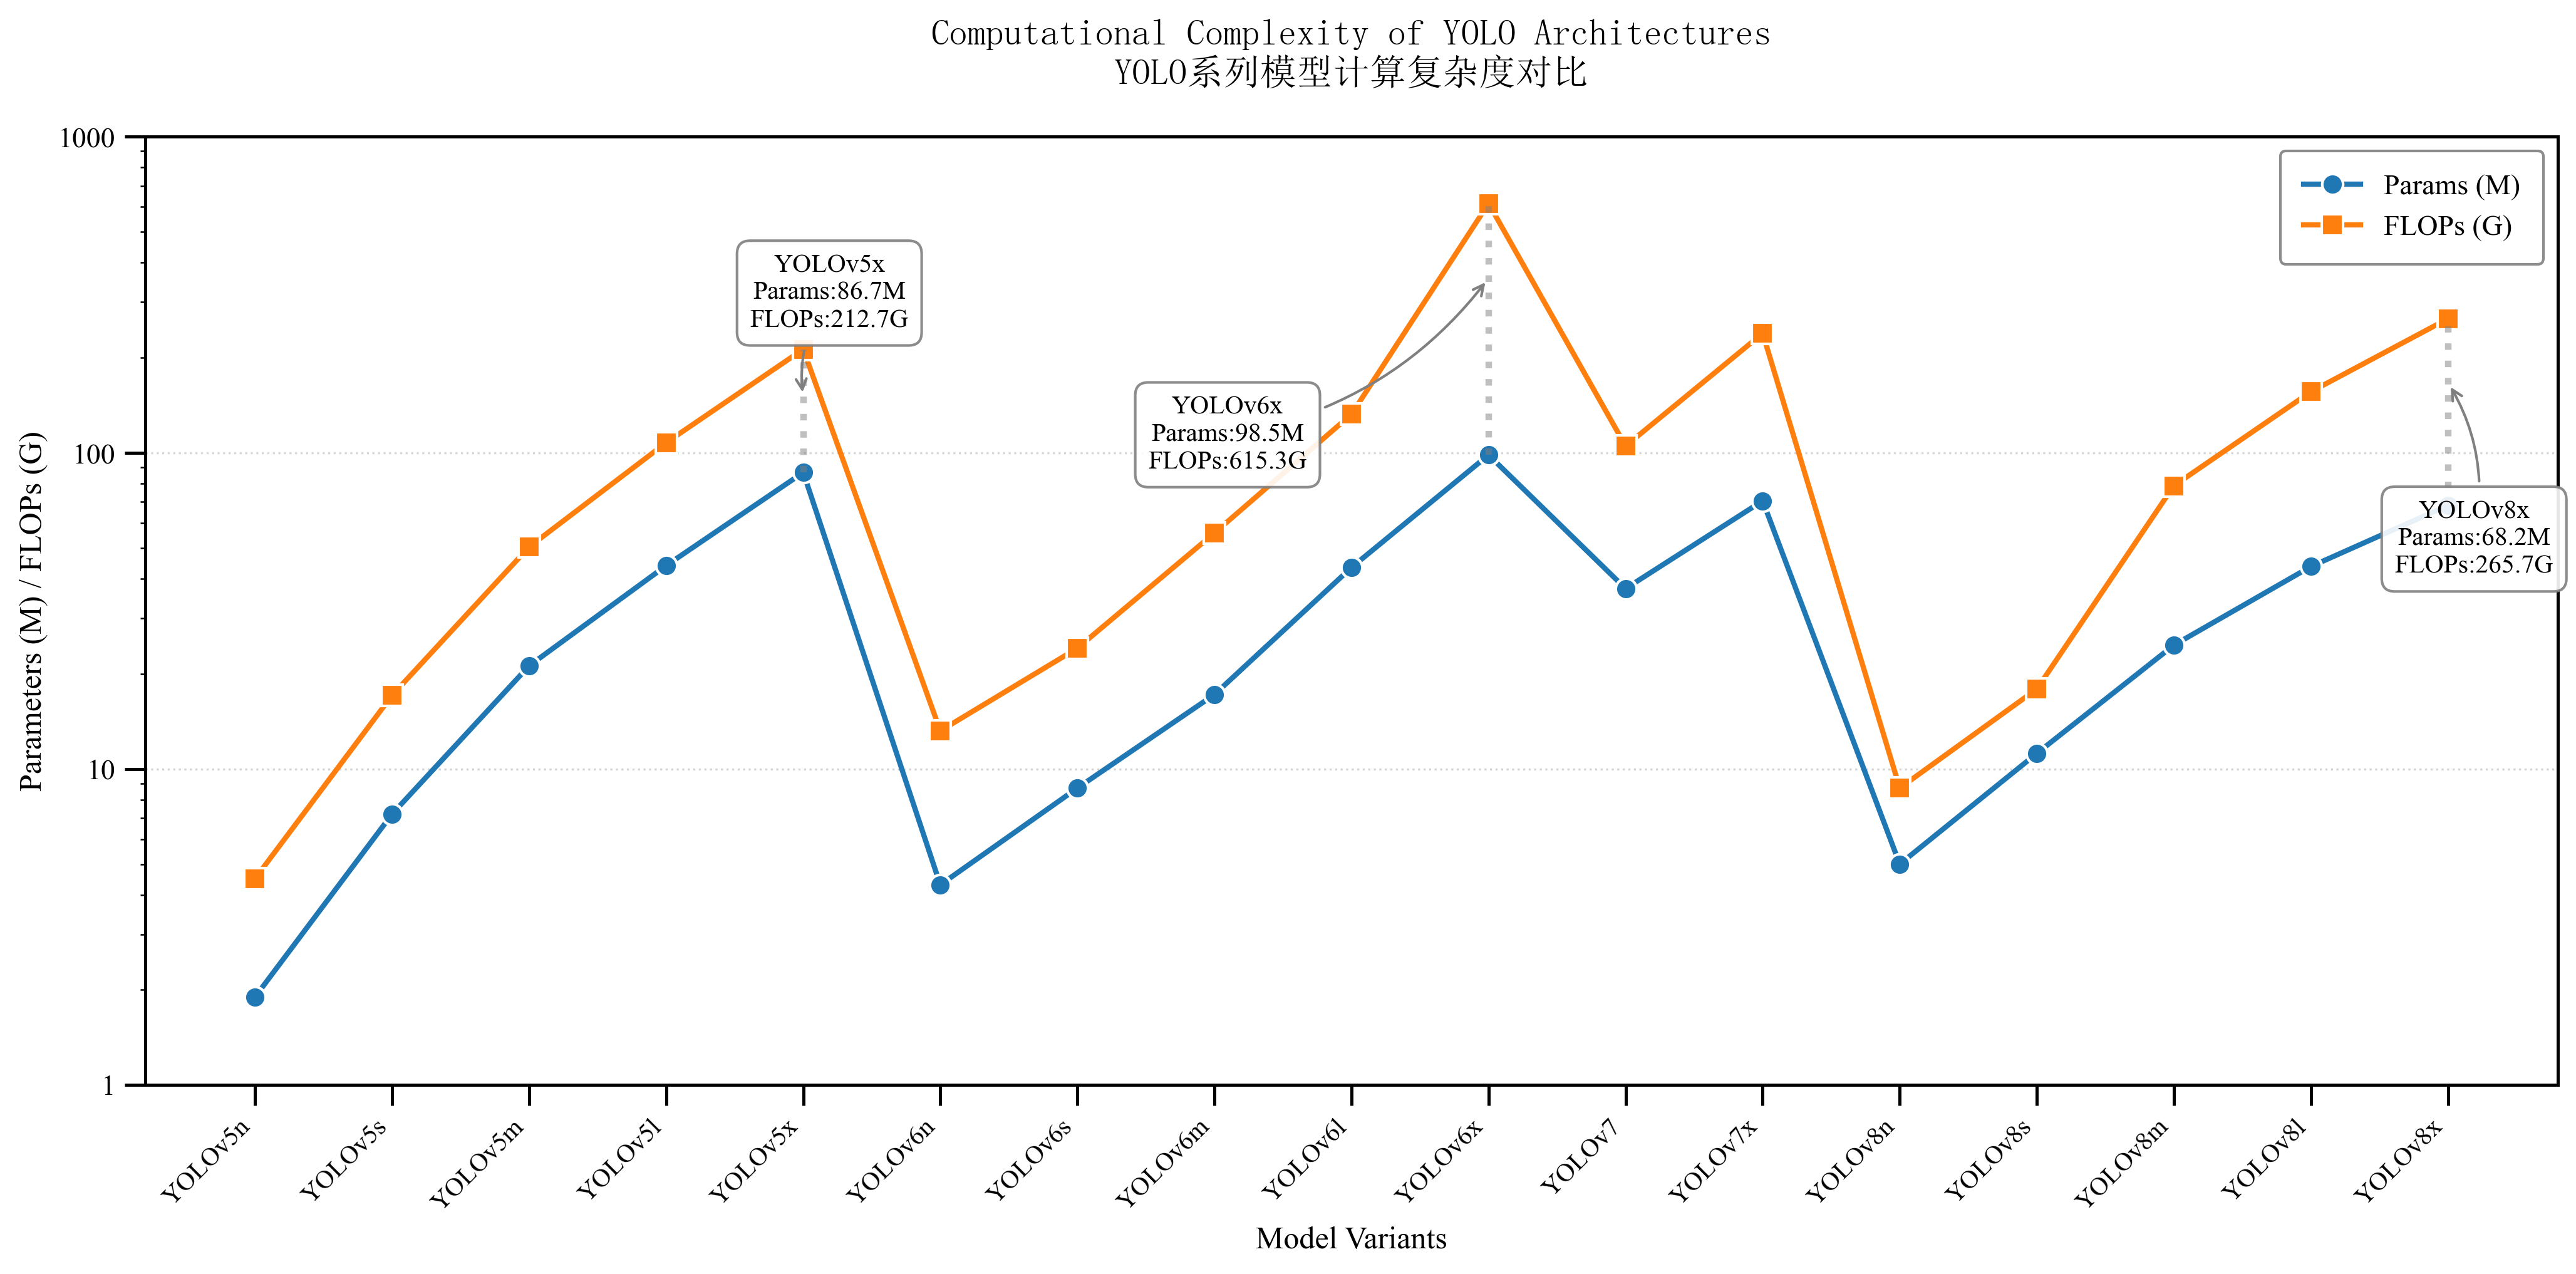

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib import rcParams

# ==================== 学术图表配置 ====================
# ==================== 字体设置（中英文） ====================
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 14,  # 小五字号 ≈ 10.5 pt
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False
})

# 设置中文字体为宋体，字号为小五（约10.5pt）
try:
    chinese_font = fm.FontProperties(fname='C:/Windows/Fonts/simsun.ttc', size=14)
except:
    try:
        chinese_font = fm.FontProperties(fname='/System/Library/Fonts/STHeiti Medium.ttc', size=14)
    except:
        chinese_font = fm.FontProperties(size=14)

# ==================== 数据准备 ====================
models = ['YOLOv5n', 'YOLOv5s', 'YOLOv5m', 'YOLOv5l', 'YOLOv5x',
          'YOLOv6n', 'YOLOv6s', 'YOLOv6m', 'YOLOv6l', 'YOLOv6x',
          'YOLOv7', 'YOLOv7x', 'YOLOv8n', 'YOLOv8s', 'YOLOv8m', 'YOLOv8l', 'YOLOv8x']

params = [1.9, 7.2, 21.2, 43.99, 86.7, 
          4.3, 8.7, 17.2, 43.4, 98.5,
          37.2, 70.5, 5.0, 11.2, 24.64, 43.7, 68.2]  # 单位：M

flops = [4.5, 17.1, 50.4, 107.7, 212.7, 
         13.2, 24.1, 55.8, 132.5, 615.3,
         105.1, 238.9, 8.7, 17.9, 78.7, 156.1, 265.7]  # 单位：G

x = np.arange(len(models))

# ==================== 关键点定义 ====================
key_points = [
    (4, 'YOLOv5x\nParams:86.7M\nFLOPs:212.7G', (10, 40)),
    (9, 'YOLOv6x\nParams:98.5M\nFLOPs:615.3G', (-100, -60)),
    (16, 'YOLOv8x\nParams:68.2M\nFLOPs:265.7G', (10, -60))
]

# ==================== 图表绘制 ====================
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)
fig.subplots_adjust(bottom=0.25)

# 1. 绘制主曲线
params_line = ax.plot(x, params, marker='o', markersize=8, 
                     markeredgewidth=1, markeredgecolor='w',
                     linewidth=2, color='#1f77b4', label='Params (M)')[0]
flops_line = ax.plot(x, flops, marker='s', markersize=8,
                   markeredgewidth=1, markeredgecolor='w',
                   linewidth=2, color='#ff7f0e', label='FLOPs (G)')[0]

# 2. 关键点标注
for idx, text, offset in key_points:
    # 连接线
    ax.plot([x[idx], x[idx]], [params[idx], flops[idx]], 
           linestyle=':', color='gray', alpha=0.5)
    
    # 标注框
    ax.annotate(text, xy=(x[idx], (params[idx]+flops[idx])/2),
               xytext=offset, textcoords='offset points',
               ha='center', va='center', fontsize=10,
               bbox=dict(boxstyle='round,pad=0.5', 
                        fc='white', ec='gray', alpha=0.9),
               arrowprops=dict(arrowstyle='->', 
                             connectionstyle='arc3,rad=0.2',
                             color='gray'))

# ==================== 格式设置 ====================
# 1. 坐标轴
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax.set_yscale('log')
ax.set_ylim(1, 1000)
ax.set_yticks([1, 10, 100, 1000])
ax.set_yticklabels(['1', '10', '100', '1000'])

# 2. 标签和标题
ax.set_xlabel('Model Variants', fontsize=12)
ax.set_ylabel('Parameters (M) / FLOPs (G)', fontsize=12)
ax.set_title('Computational Complexity of YOLO Architectures\nYOLO系列模型计算复杂度对比',
           fontproperties=chinese_font, pad=20)

# 3. 图例和网格
ax.legend(frameon=True, framealpha=0.9, 
         edgecolor='gray', facecolor='white',
         fontsize=11, borderpad=0.8)
ax.grid(True, axis='y', linestyle=':', alpha=0.5)

# ==================== 输出 ====================
plt.tight_layout()
# plt.savefig('YOLO_Complexity.pdf', format='pdf', bbox_inches='tight')
plt.savefig('YOLO_Complexity.png', dpi=300, bbox_inches='tight')
plt.show()

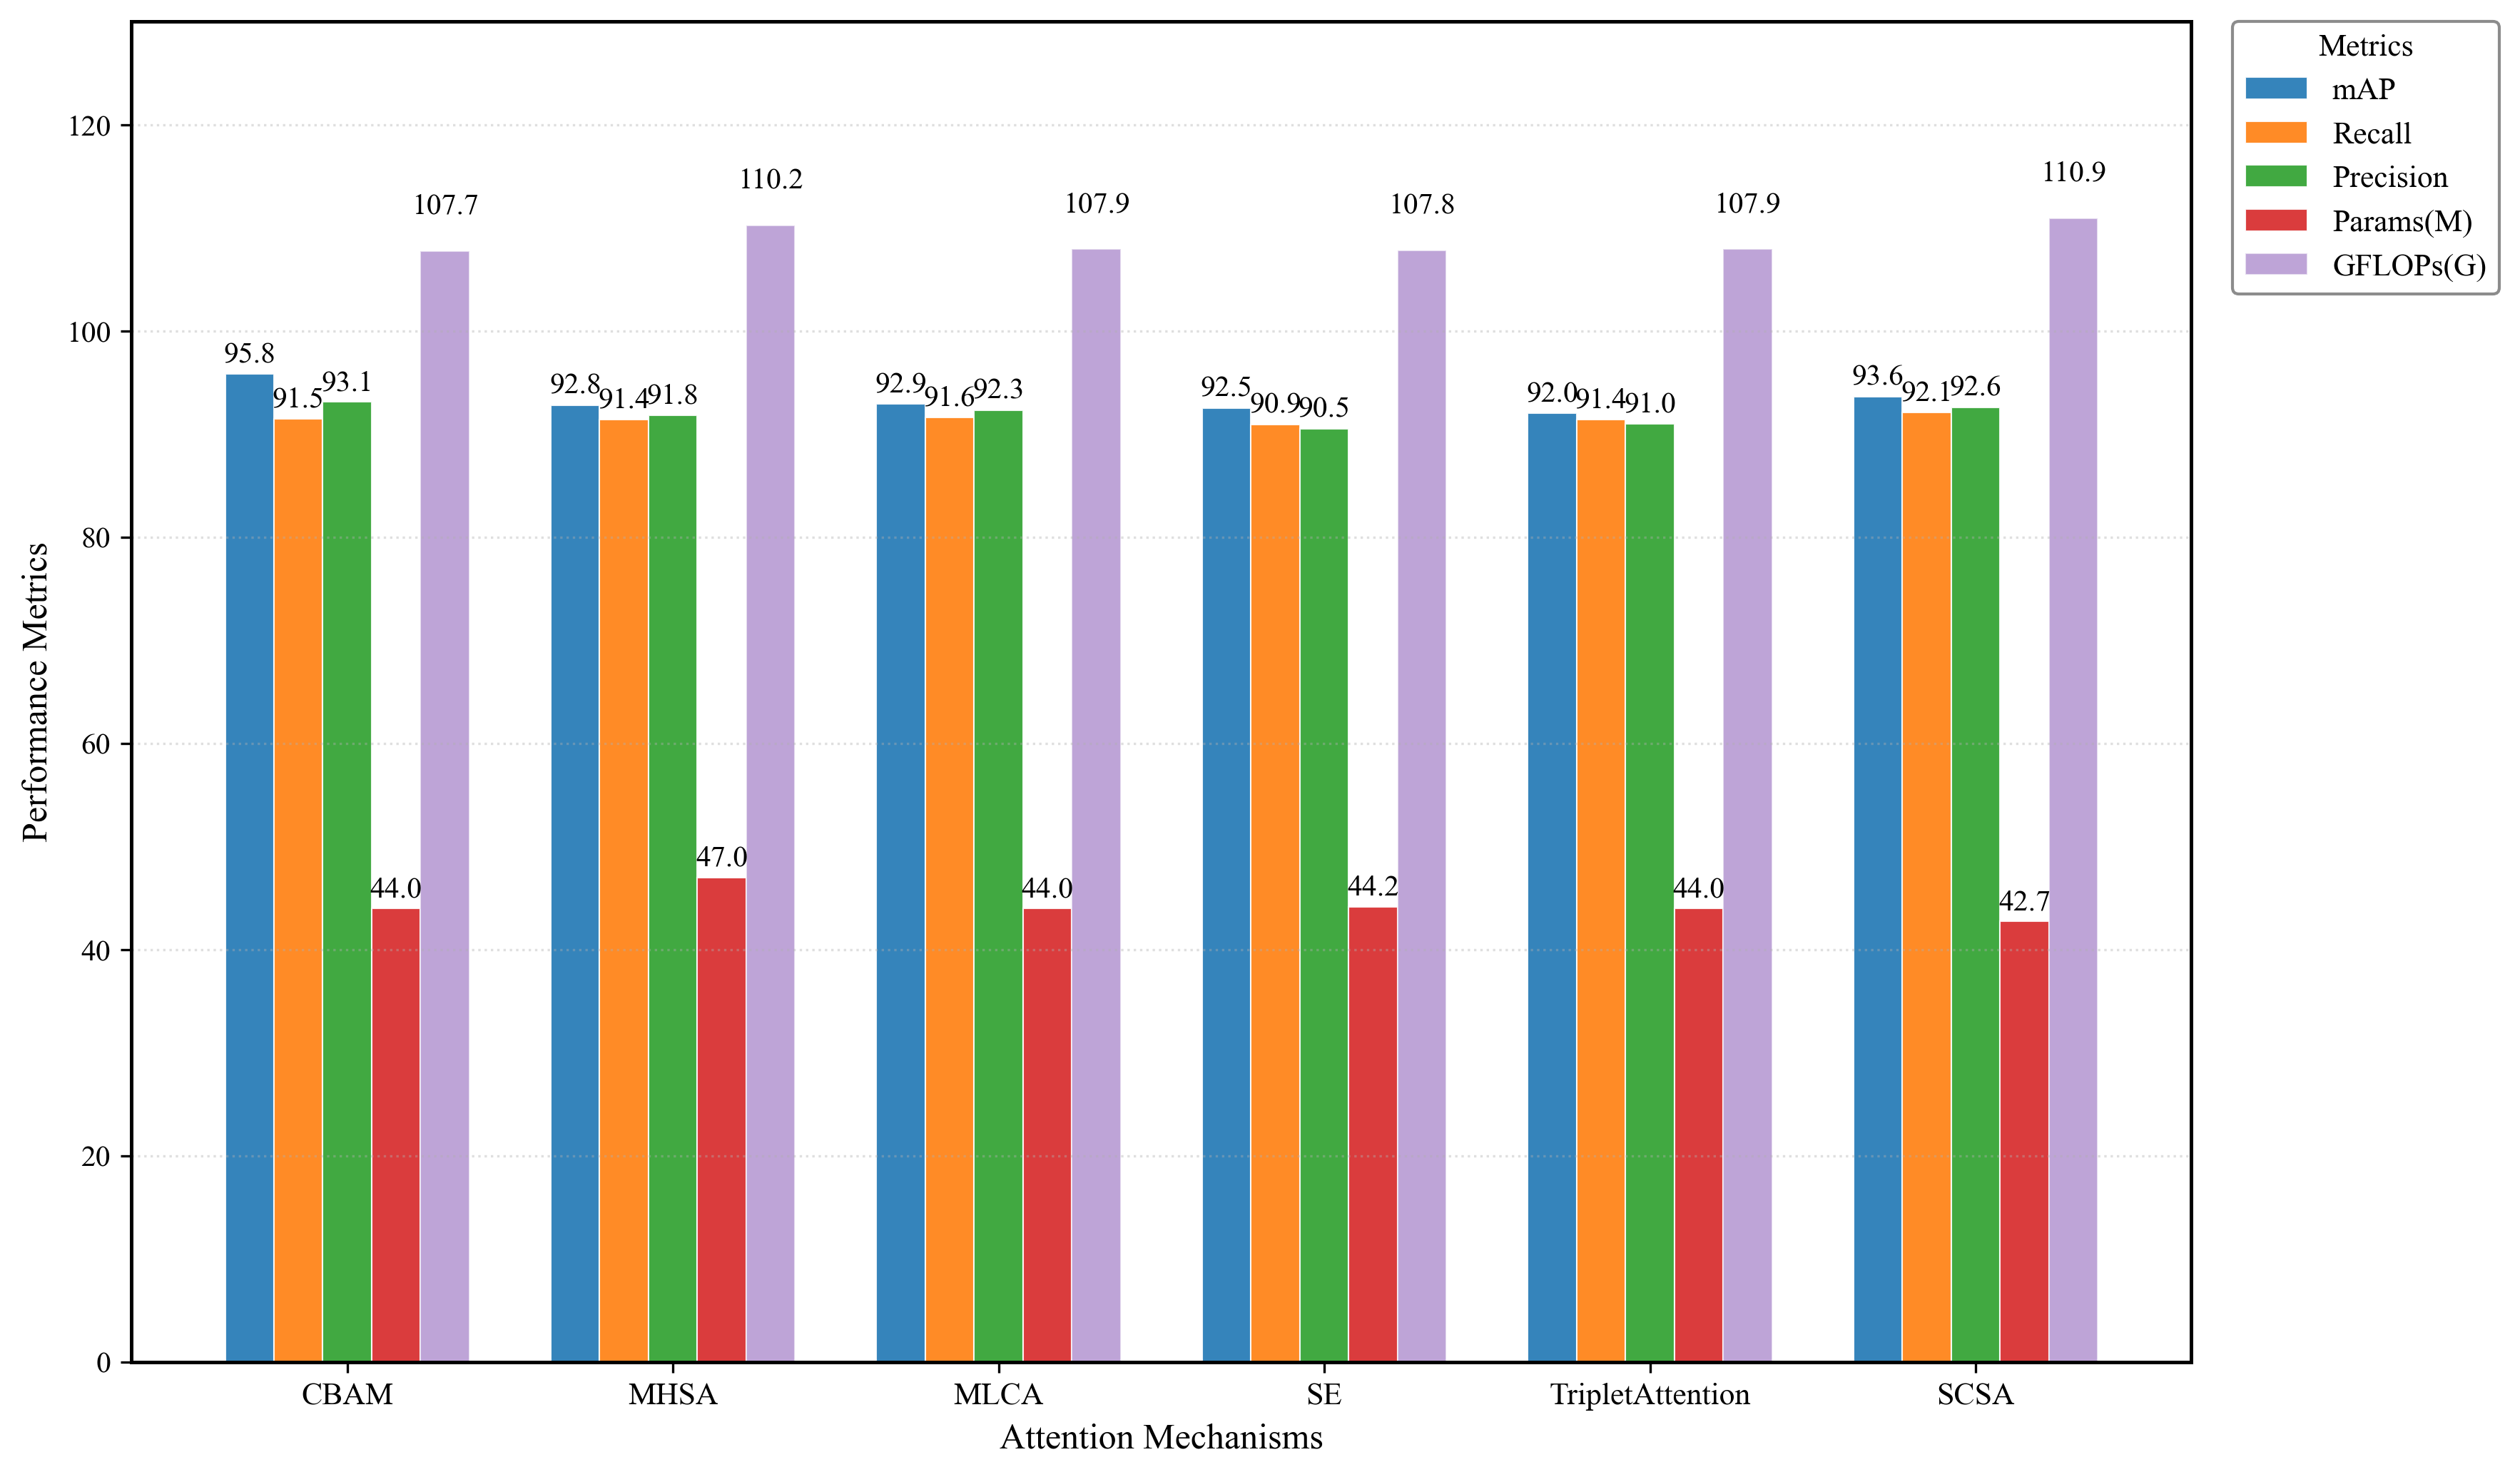

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib import rcParams

# ==================== 字体设置 ====================
# 英文字体：Times New Roman
font_eng = fm.FontProperties(family='Times New Roman', size=10.5)

rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False
})

# 中文宋体
try:
    chinese_font = font_eng
except:
    try:
        chinese_font = font_eng
    except:
        chinese_font = font_eng

# ==================== 数据准备 ====================
models = ['CBAM', 'MHSA', 'MLCA', 'SE', 'TripletAttention', 'SCSA']
metrics = ['mAP', 'Recall', 'Precision', 'Params(M)', 'GFLOPs(G)']
data = {
    'CBAM': [95.8, 91.5, 93.1, 43.99, 107.7],
    'MHSA': [92.8, 91.4, 91.8, 46.99, 110.2],
    'MLCA': [92.9, 91.6, 92.3, 43.99, 107.9],
    'SE': [92.5, 90.9, 90.5, 44.18, 107.8],
    'TripletAttention': [92.0, 91.4, 91.0, 43.99, 107.9],
    'SCSA': [93.6, 92.1, 92.6, 42.74, 110.9]
}

# ==================== 图表绘制 ====================
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bar_width = 0.15
index = np.arange(len(models))
opacity = 0.9

for i, metric in enumerate(metrics):
    alpha = 0.6 if metric == 'GFLOPs(G)' else opacity
    ax.bar(index + i * bar_width, [data[model][i] for model in models],
           bar_width, color=colors[i], alpha=alpha,
           edgecolor='white', linewidth=0.5, label=metric)

# 数值标注统一字体
for i, model in enumerate(models):
    for j, metric in enumerate(metrics):
        height = data[model][j]
        y_pos = height + 0.5 if metric != 'GFLOPs(G)' else min(height + 3, ax.get_ylim()[1] - 2)
        ax.text(index[i] + j * bar_width, y_pos,
                f'{height:.1f}' if height >= 10 else f'{height:.2f}',
                ha='center', va='bottom',
                fontproperties=font_eng, fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1) if metric == 'GFLOPs(G)' else None)

# ==================== 格式设置 ====================
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1),
          borderaxespad=0., frameon=True,
          framealpha=0.9, edgecolor='gray',
          title='Metrics', title_fontproperties=font_eng,
          prop=font_eng)

ax.set_xticks(index + 2 * bar_width)
ax.set_xticklabels(models, fontproperties=chinese_font)

ax.set_ylim(0, 130)
ax.set_xlabel('Attention Mechanisms', fontsize=12, fontproperties=font_eng)
ax.set_ylabel('Performance Metrics', fontsize=12, fontproperties=font_eng)


ax.grid(True, axis='y', linestyle=':', alpha=0.4)
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# ==================== 输出 ====================
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('不同注意力机制对比.png', dpi=300, bbox_inches='tight')
plt.show()


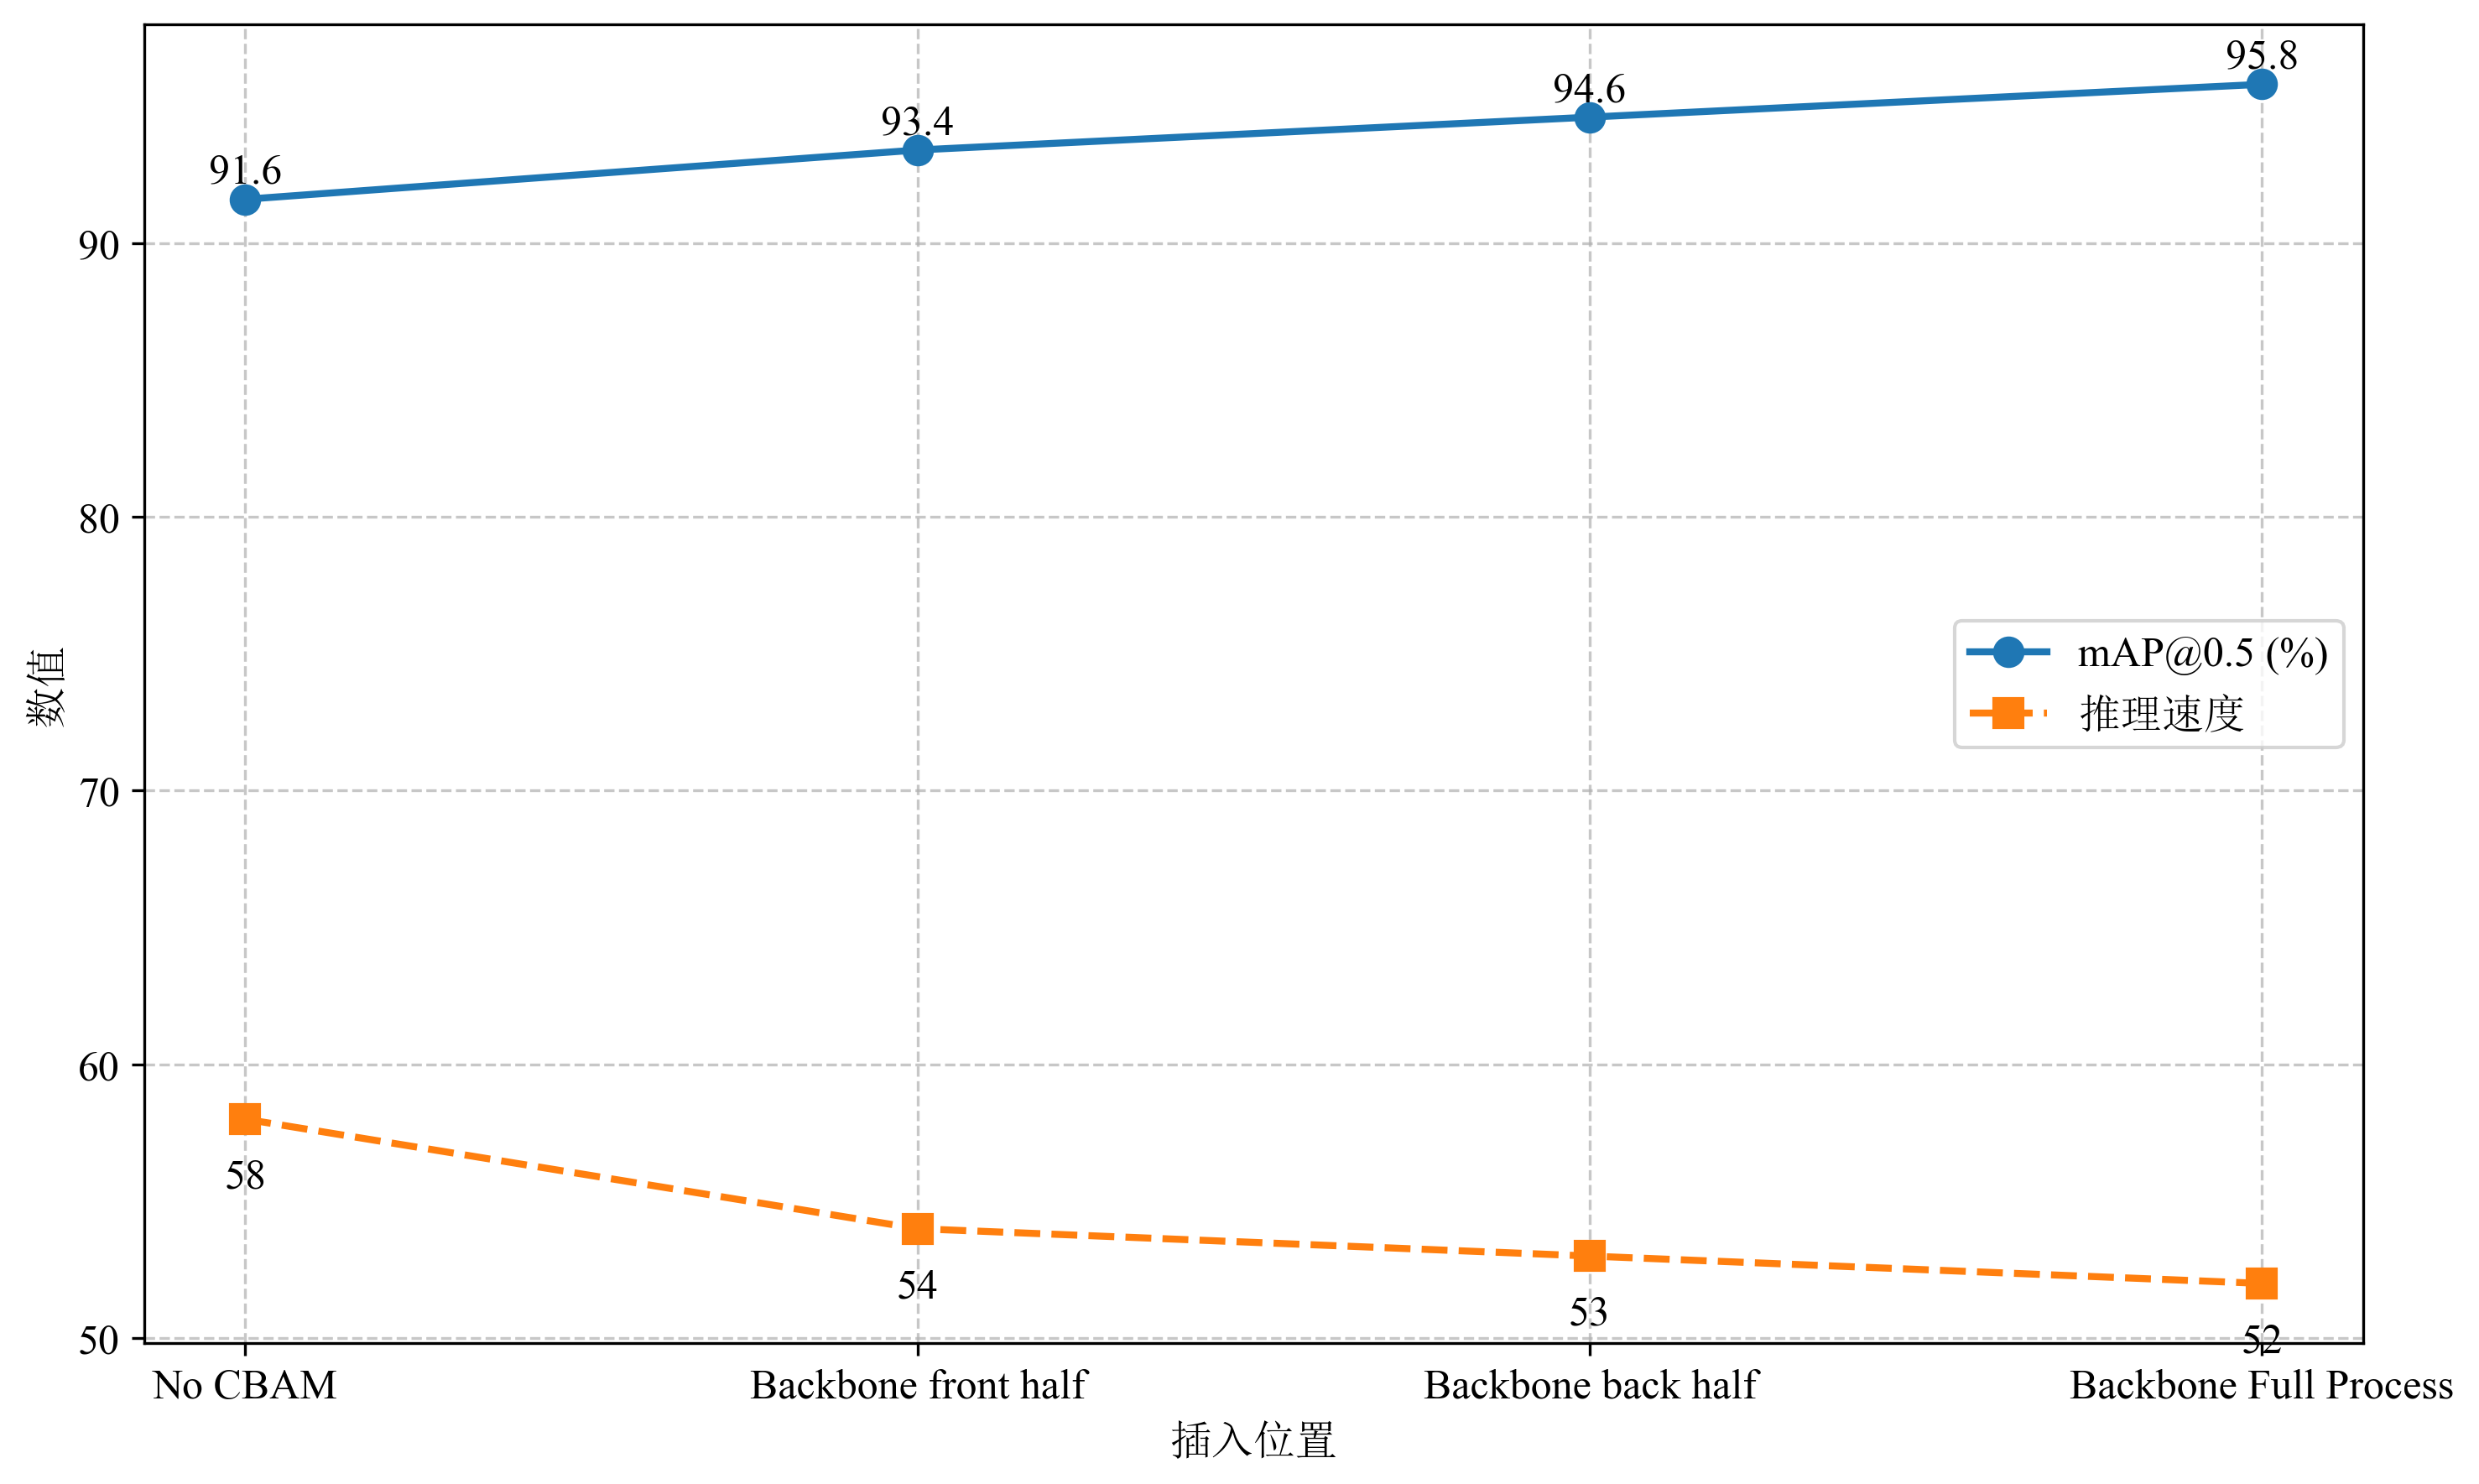

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ========== 字体准备 ==========
font_path_zh = 'C:/Windows/Fonts/simsun.ttc'     # 宋体
font_path_en = 'C:/Windows/Fonts/times.ttf'      # Times New Roman

font_zh = fm.FontProperties(fname=font_path_zh, size=12)
font_en = fm.FontProperties(fname=font_path_en, size=12)

# ========== 数据 ==========
positions = ['No CBAM', 'Backbone front half', 'Backbone back half', 'Backbone Full Process']
map50 = [91.6, 93.4, 94.6, 95.8]
fps = [58, 54,53, 52]

# ========== 绘图 ==========
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 画折线图
line1, = ax.plot(positions, map50, marker='o', linestyle='-', linewidth=2, markersize=8,
                 color='#1f77b4')
line2, = ax.plot(positions, fps, marker='s', linestyle='--', linewidth=2, markersize=8,
                 color='#ff7f0e')

# 添加标注
for i, (m, f) in enumerate(zip(map50, fps)):
    ax.text(positions[i], m + 0.6, f'{m:.1f}', ha='center', fontproperties=font_en, fontsize=12)
    ax.text(positions[i], f - 2.5, f'{f}', ha='center', fontproperties=font_en, fontsize=12)

# 设置坐标轴标签
ax.set_xlabel('插入位置', fontproperties=font_zh, fontsize=12)
ax.set_ylabel('数值', fontproperties=font_zh, fontsize=12)

# 设置标题（分开设置中英文字体）
# ax.set_title('消融实验对比结果 Ablation Experiment Comparison',
#              fontproperties=font_zh, fontsize=14, pad=15)

# 设置刻度字体
ax.set_xticks(range(len(positions)))
ax.set_xticklabels(positions, fontproperties=font_en, fontsize=12)
ax.tick_params(axis='y', labelsize=11)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_en)

# 图例中分别设置字体
legend_labels = ['mAP@0.5 (%)', '推理速度']
legend = ax.legend([line1, line2], legend_labels, loc='center right', fontsize=11)
for text in legend.get_texts():
    if any('\u4e00' <= ch <= '\u9fff' for ch in text.get_text()):
        text.set_fontproperties(font_zh)
    else:
        text.set_fontproperties(font_en)

# 网格与布局
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('消融实验.png', dpi=300)
plt.show()


In [3]:
import os
fonts = os.listdir("C:/Windows/Fonts")
print([f for f in fonts if "times" in f.lower()])


['times.ttf', 'timesbd.ttf', 'timesbi.ttf', 'timesi.ttf']


C:\Users\Sqy\AppData\Local\Temp\ipykernel_19880\1033263213.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(methods, fontproperties=font_zh, fontsize=11)


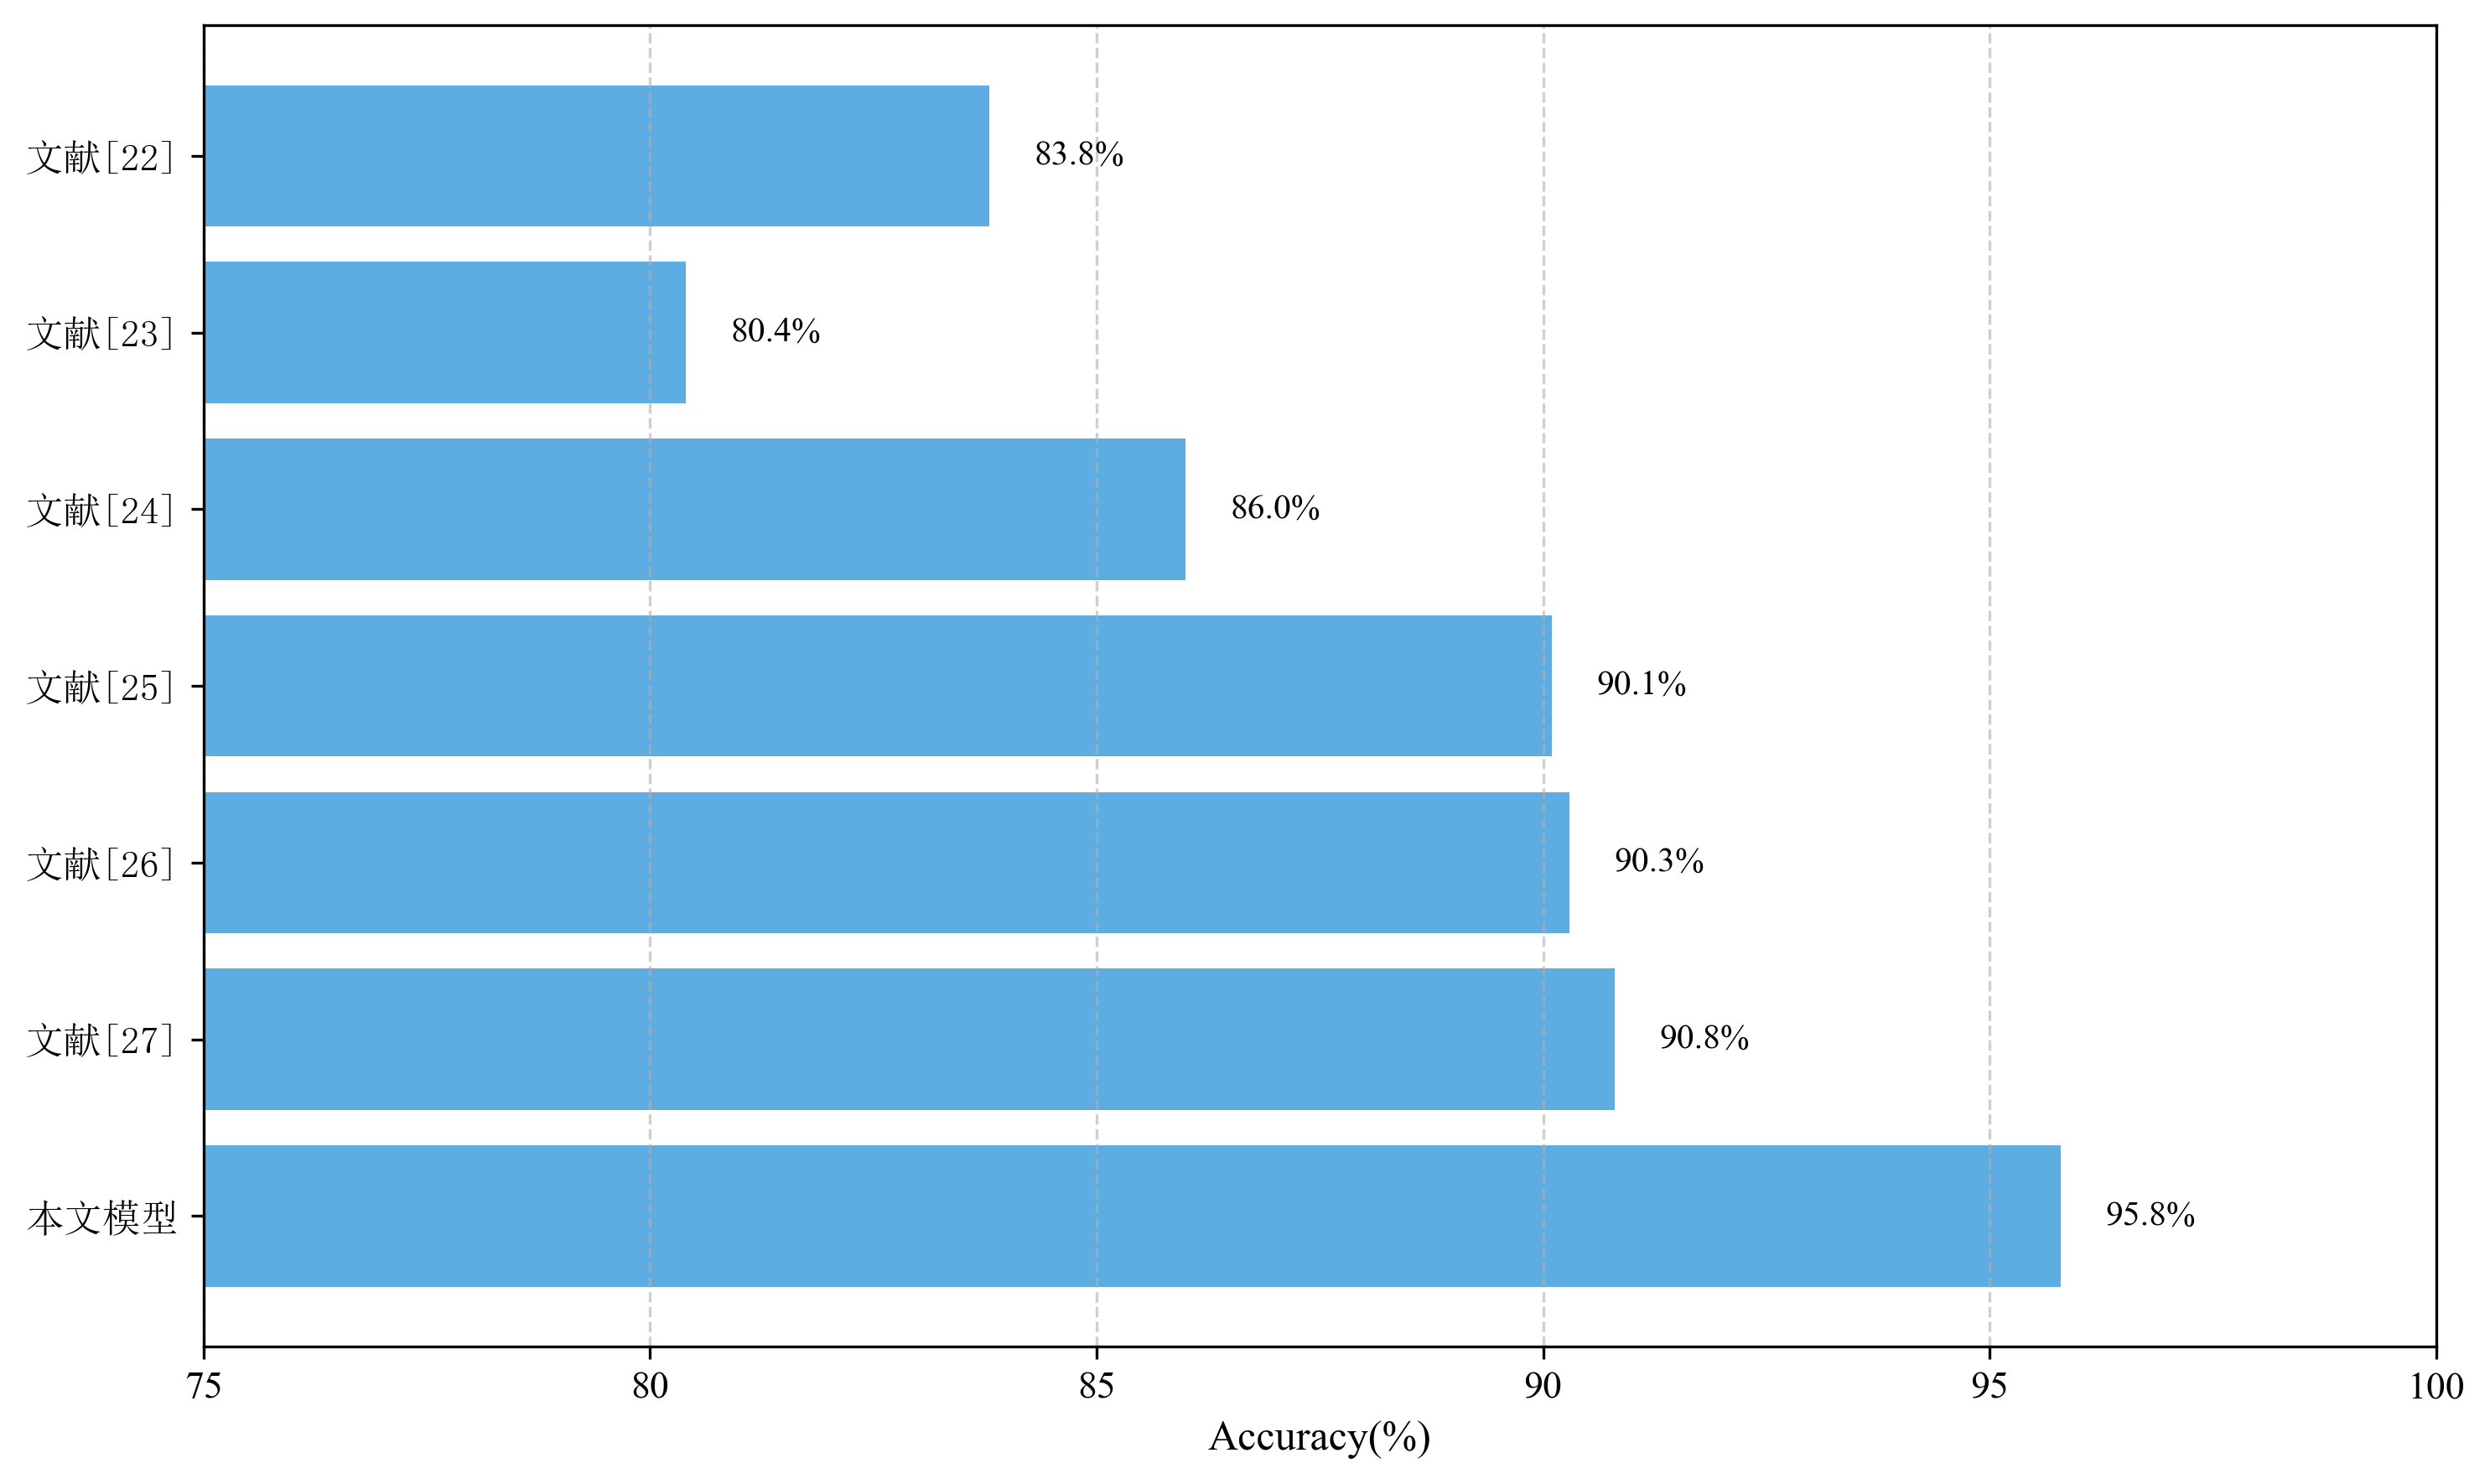

In [13]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ========== 字体准备 ==========
font_path_zh = 'C:/Windows/Fonts/simsun.ttc'     # 宋体
font_path_en = 'C:/Windows/Fonts/times.ttf'      # Times New Roman

font_zh = fm.FontProperties(fname=font_path_zh, size=11)
font_en = fm.FontProperties(fname=font_path_en, size=11)

# ========== 数据 ==========
methods = ['文献[22]', '文献[23]', '文献[24]', '文献[25]', '文献[26]', '文献[27]', '本文模型']
accuracies = [83.8, 80.4, 86.0, 90.1, 90.3, 90.8, 95.8]

# 倒序绘制
methods = methods[::-1]
accuracies = accuracies[::-1]

# ========== 绘图 ==========
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
bars = ax.barh(methods, accuracies, color='#5DADE2')

# 添加数值标签（英文字体）
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va='center', fontsize=10, fontproperties=font_en)

# 轴标签与标题（中英分开设置字体）
ax.set_xlabel('Accuracy(%)', fontsize=12, fontproperties=font_en)
# ax.set_title('不同方法在书脊数据集上的分割准确率对比\nComparison of Segmentation Accuracy on Book Spine Dataset',
#              fontsize=14, fontproperties=font_zh, pad=15)

# 设置Y轴字体
ax.set_yticklabels(methods, fontproperties=font_zh, fontsize=11)

# 设置X轴刻度字体（英文）
for label in ax.get_xticklabels():
    label.set_fontproperties(font_en)
    label.set_fontsize(11)

# 设置网格
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_xlim(75, 100)

# 输出
plt.tight_layout()
plt.savefig('文献对比.png', dpi=600)
plt.show()
